# Lab 2: Classification Using KNN and RNN Algorithms

**Name:** Aashish Shrestha

**Course:** Advance Big Data And Data Mining

**Lab Assignment:** Lab 2 &ndash; Classification Using KNN and Radius Neighbors (RNN) Algorithms


## What this lab is about

In this lab I compare two neighbour-based classifiers on the **Wine dataset** from
scikit-learn:

- **KNN (K-Nearest Neighbors)** &ndash; looks at a *fixed number* of the closest wines
  (the `k` nearest) and takes a majority vote.
- **RNN (Radius Neighbors)** &ndash; looks at *every* wine inside a *fixed distance*
  (the `radius`) and takes a majority vote.

The Wine dataset has 178 samples, 13 chemical measurements per wine, and 3 wine
classes. My goal is to try several values of `k` and several values of `radius`,
record the test accuracy for each, plot how accuracy changes, and figure out which
model works better here and why.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset, splitting, models, and the scoring metric
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)

## Step 1: Load and prepare the dataset

First I load the Wine data, put it into a pandas DataFrame so it is easy to look at,
do some quick exploration, and then split it into training and testing sets.


In [2]:
# Load the Wine dataset that ships with scikit-learn
wine = load_wine()

X = wine.data            # the 13 features
y = wine.target          # the class label (0, 1, or 2)
feature_names = wine.feature_names
class_names = list(wine.target_names)

# Build a DataFrame so exploring the data is easier
df = pd.DataFrame(X, columns=feature_names)
df["wine_class"] = y

print("Rows (samples):", X.shape[0])
print("Columns (features):", X.shape[1])
print("Classes:", class_names)
df.head()

Rows (samples): 178
Columns (features): 13
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Below is a quick statistical summary of every feature. Notice how different the scales are &ndash; most values sit below 20, but **proline** runs from about 278 all the way up to 1680. That single column is much larger than the rest, and it will matter a lot later when we set the radius for RNN.

In [3]:
# Basic statistics for each feature (rounded for readability)
df[feature_names].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


Now the class distribution. The three classes are not perfectly equal, but they are reasonably balanced, so no class is being ignored.

class_0 (label 0): 59 samples
class_1 (label 1): 71 samples
class_2 (label 2): 48 samples


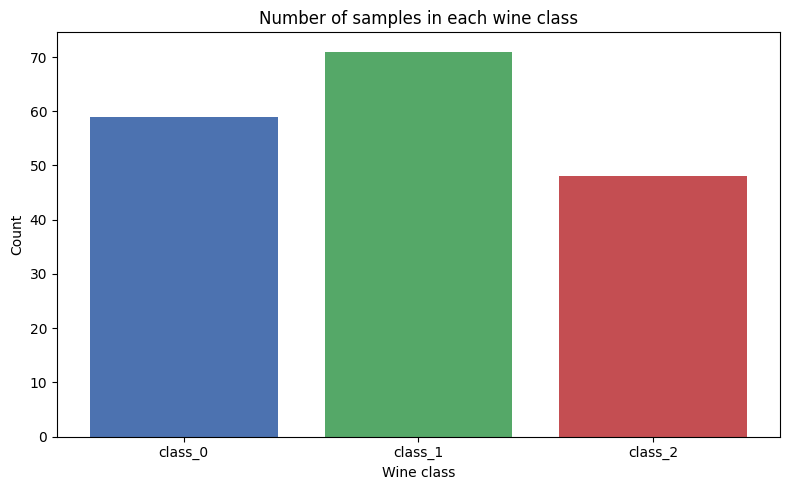

In [4]:
# How many wines fall in each class?
counts = df["wine_class"].value_counts().sort_index()
for cls, n in counts.items():
    print(f"{class_names[cls]} (label {cls}): {n} samples")

# Bar chart of the class distribution
plt.bar([class_names[i] for i in counts.index], counts.values,
        color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Number of samples in each wine class")
plt.ylabel("Count")
plt.xlabel("Wine class")
plt.tight_layout()
plt.show()

### Train / test split

I split the data into **80% training** and **20% testing**. Two small decisions here:

- `random_state=42` &ndash; so the split is the same every time the notebook runs
  (results stay reproducible).
- `stratify=y` &ndash; so the train and test sets keep the same class balance as the
  full dataset. With only 178 rows this stops one class from being under-represented
  in the test set by chance.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])
print("Test set class counts:",
      pd.Series(y_test).value_counts().sort_index().to_dict())

Training samples: 142
Testing samples:  36
Test set class counts: {0: 12, 1: 14, 2: 10}


## Step 2: K-Nearest Neighbors (KNN)

Here I train a KNN classifier for each value of **k = 1, 5, 11, 15, 21**. For every
`k` I fit on the training data, predict on the test data, and store the accuracy so I
can compare and plot it afterwards.


In [6]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    print(f"k = {k:>2}  ->  accuracy = {acc:.4f}")

# Tidy table of the results
knn_results = pd.DataFrame({"k": k_values, "accuracy": knn_accuracies})
knn_results

k =  1  ->  accuracy = 0.7778
k =  5  ->  accuracy = 0.8056
k = 11  ->  accuracy = 0.8056
k = 15  ->  accuracy = 0.8056
k = 21  ->  accuracy = 0.8056


,k,accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


## Step 3: Radius Neighbors (RNN)

Now the Radius Neighbors classifier, using **radius = 350, 400, 450, 500, 550, 600**.

**Why such large radius values?** RNN measures distance between wines, and on the raw
(un-scaled) data those distances are driven almost entirely by the `proline` feature,
which is far larger than everything else. The average distance between two wines is
around 350 and the largest is about 1400, so radii in the hundreds are exactly the
right size. (If I had standardised the features first, every distance would shrink to
roughly 0&ndash;12 and a radius of 350 would simply grab the whole dataset &ndash;
so I deliberately kept the data raw.)

I also set `outlier_label='most_frequent'`. If a test wine happens to have *no*
training wines inside its radius, RNN would normally throw an error; this setting tells
it to just fall back to the most common class instead, which keeps the code safe for
the smaller radii.


In [7]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for r in radius_values:
    model = RadiusNeighborsClassifier(radius=r, outlier_label="most_frequent")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)
    print(f"radius = {r:>3}  ->  accuracy = {acc:.4f}")

# Tidy table of the results
rnn_results = pd.DataFrame({"radius": radius_values, "accuracy": rnn_accuracies})
rnn_results

radius = 350  ->  accuracy = 0.7222
radius = 400  ->  accuracy = 0.6944
radius = 450  ->  accuracy = 0.6944
radius = 500  ->  accuracy = 0.6944
radius = 550  ->  accuracy = 0.6667
radius = 600  ->  accuracy = 0.6667


,radius,accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


## Step 4: Visualise and compare the results

Two line plots below: accuracy vs `k` for KNN, and accuracy vs `radius` for RNN. I
also drop in a dashed line for the **majority-class baseline** (what you would get by
blindly guessing the most common class every time) so it is clear both models are
actually learning something.


In [8]:
# Majority-class baseline: always predict the most common class from training
from collections import Counter
majority_class = Counter(y_train).most_common(1)[0][0]
baseline_acc = accuracy_score(y_test, [majority_class] * len(y_test))
print(f"Majority-class baseline accuracy: {baseline_acc:.4f}")

Majority-class baseline accuracy: 0.3889


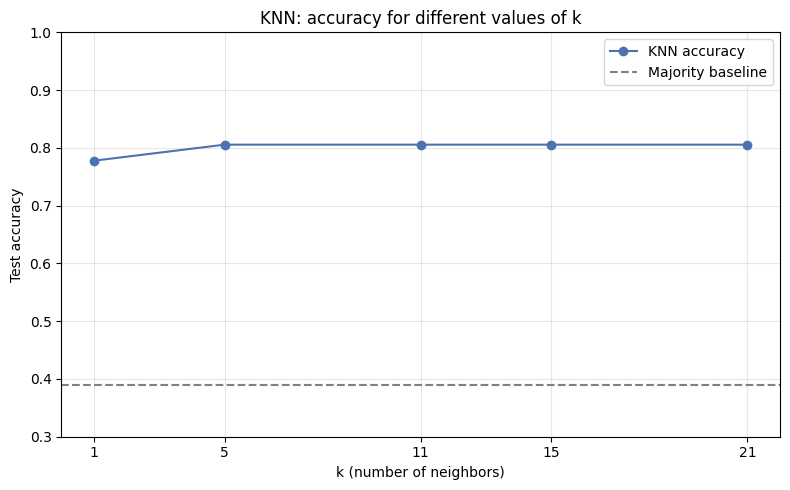

In [9]:
# --- KNN accuracy trend ---
plt.plot(k_values, knn_accuracies, marker="o", color="#4C72B0", label="KNN accuracy")
plt.axhline(baseline_acc, color="grey", linestyle="--", label="Majority baseline")
plt.title("KNN: accuracy for different values of k")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test accuracy")
plt.xticks(k_values)
plt.ylim(0.3, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

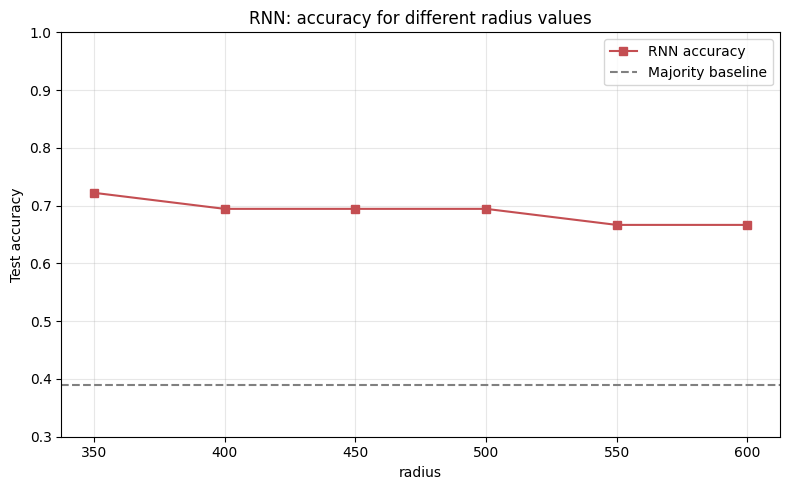

In [10]:
# --- RNN accuracy trend ---
plt.plot(radius_values, rnn_accuracies, marker="s", color="#C44E52", label="RNN accuracy")
plt.axhline(baseline_acc, color="grey", linestyle="--", label="Majority baseline")
plt.title("RNN: accuracy for different radius values")
plt.xlabel("radius")
plt.ylabel("Test accuracy")
plt.xticks(radius_values)
plt.ylim(0.3, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

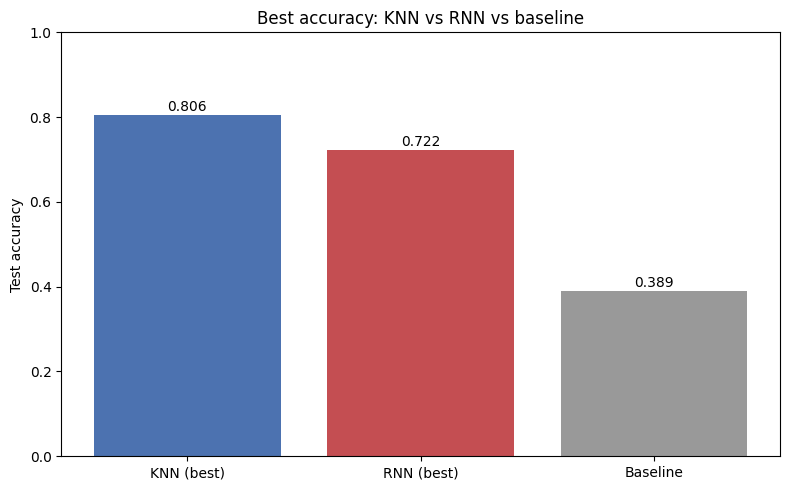

In [11]:
# --- Best of each, side by side ---
best_knn = max(knn_accuracies)
best_rnn = max(rnn_accuracies)

plt.bar(["KNN (best)", "RNN (best)", "Baseline"],
        [best_knn, best_rnn, baseline_acc],
        color=["#4C72B0", "#C44E52", "#999999"])
for i, v in enumerate([best_knn, best_rnn, baseline_acc]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.title("Best accuracy: KNN vs RNN vs baseline")
plt.ylabel("Test accuracy")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Observations and comparison

### Based on Result What happened with KNN
At **k = 1** the accuracy was about **0.78**. That is the lowest KNN score, which makes
sense: with a single neighbor the model just copies whatever one wine happens to be
closest, so a single odd point can flip the answer. Moving to **k = 5** pushed accuracy
up to about **0.81**, and it then stayed flat at that level for **k = 11, 15, and 21**.
So once there were enough neighbors to smooth out the noise, adding even more did not
help &ndash; the classes are separated well enough that a small handful of neighbors
already gives a stable vote.

### Based on Result What happened with RNN
RNN did the opposite. Its **best** score came from the **smallest** radius (350) at
about **0.72**, and accuracy slowly slid down as the radius grew, reaching about
**0.67** at radius 600. The reason is intuitive: a bigger radius scoops up more and more
wines around each test point, including wines from other classes, so the majority vote
gets diluted and the model drifts toward the most common class.

### KNN vs RNN
KNN clearly won here &ndash; roughly **0.81** at its best versus about **0.67&ndash;0.72**
for RNN. Both beat the majority-class baseline of about **0.39**, so both genuinely
learned patterns in the data, but KNN was the stronger and more stable choice.

The core difference is *how each one picks neighbors*:

- **KNN** always uses a fixed **count** of neighbors, so every test point gets the same
  size, balanced vote no matter where it sits.
- **RNN** uses a fixed **distance**, so in crowded regions it grabs a huge number of
  points (over-smoothing toward the majority) and in sparse regions it can grab very few
  or none.

Because `proline` dominates the raw distance, the RNN radius is basically just a
"proline window", which is a blunter rule than "the k closest wines overall". That is a
big part of why KNN edged it out on this dataset.


## When would you pick KNN vs RNN?

**KNN when:**
- You are not sure what a good distance cut-off should be (KNN only needs a count, not a
  distance).
- The data has regions of different density &ndash; a fixed `k` stays robust because it
  never runs out of neighbors or grabs too many.
- You want something simple and dependable, which is what we saw here.

**RNN when:**
- The data density is fairly even *and* you know a sensible distance scale.
- You actually *want* the model to react to local density &ndash; dense areas vote with
  more points, sparse areas with fewer.
- You want to spot outliers, since a point with no neighbors inside the radius is flagged
  naturally.
- Just remember RNN really needs the features on comparable scales (or a carefully chosen
  radius) to behave well.
